In [12]:
import numpy as np
import matplotlib.pyplot as plt

# New Least Squares Method
def custom_least_squares(X, Y):
    A = np.stack([X, np.ones(len(X))]).T
    #Transpose of matrix
    transpose_A = A.T @ A
    transpose_Y = A.T @ Y
    coefficients = np.linalg.inv(transpose_A) @ transpose_Y
    m = coefficients[0]
    c = coefficients[1]
    return m, c

In [13]:
#Random Data
X = np.arange(0, 1.01, 0.01)
X = np.sort(X)
m_true = np.random.uniform(-5, 5)
b_true = np.random.uniform(-2, 2)
error = np.random.uniform(0, 1, size=len(X))
sign = np.random.choice([-1, 1], size=len(X))
random_error = sign*error
Y = m_true * X + b_true + random_error
print(f"Custom Line: y = {m_true:.6f}x + {b_true:.6f}")

Custom Line: y = -3.465252x + 0.178679


In [14]:
# Compare custom and numpy
m_custom, c_custom = custom_least_squares(X, Y)
# Numpy linear squares
A = np.vstack([X, np.ones(len(X))]).T
m_numpy, c_numpy = np.linalg.lstsq(A, Y, rcond=None)[0]

print("\nCustom Least Squares:")
print(f"Best fit: y = {m_custom:.6f}x + {c_custom:.6f}")
print("\nNumpy Least Squares (lstsq):")
print(f"Best fit: y = {m_numpy:.6f}x + {c_numpy:.6f}")


Custom Least Squares:
Best fit: y = -3.691585x + 0.335544

Numpy Least Squares (lstsq):
Best fit: y = -3.691585x + 0.335544


In [15]:
#Residuals and Predicted line
Y_predicted = m_custom * X + c_custom
residuals = Y - Y_predicted
print("\nResiduals (first 10):")
print(residuals[:10])

#largest/smallest residuals
idx_max = np.argmax(residuals)
idx_min = np.argmin(residuals)

print("\nMost positive residual:")
print(f"  index={idx_max}, X={X[idx_max]:.2f}, Y={Y[idx_max]:.6f}, Y_predicted={Y_predicted[idx_max]:.6f}, residual={residuals[idx_max]:.6f}")
print("\nMost negative residual:")
print(f"  index={idx_min}, X={X[idx_min]:.2f}, Y={Y[idx_min]:.6f}, Y_predicted={Y_predicted[idx_min]:.6f}, residual={residuals[idx_min]:.6f}")


Residuals (first 10):
[ 0.13734139  0.35804245  0.80758932  0.10613021 -0.70391842 -0.00200912
 -0.8756367  -0.1185495   0.2579085   0.71149632]

Most positive residual:
  index=88, X=0.88, Y=-1.906165, Y_predicted=-2.913051, residual=1.006885

Most negative residual:
  index=47, X=0.47, Y=-2.413037, Y_predicted=-1.399501, residual=-1.013537


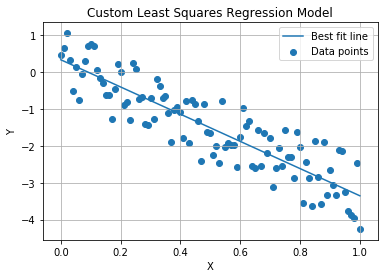

In [16]:
# Plot
plt.title("Custom Least Squares Regression Model")
plt.scatter(X, Y, label="Data points")
plt.plot(X, Y_predicted, label="Best fit line")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)
plt.show()